## Installation und Abhängigkeiten

In [30]:
pip install pandas numpy matplotlib seaborn arch statsmodels scikit-learn scipy


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: /Users/mauritzlanger/Programmierung/DMS/venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## S&P 500 GARCH Volatility Analysis
### Forschungsfrage 1: Volatilitätsprognose mit verschiedenen GARCH-Modellen
"Inwieweit können GARCH-Modelle unterschiedlicher Komplexität (GARCH(1,1), EGARCH, GJR-GARCH) die Volatilitätsdynamiken des S&P 500 Index vorhersagen, und welches Modell zeigt die beste Out-of-Sample-Prognoseperformance?"

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from arch.univariate import GARCH, EGARCH, ConstantMean, Normal, ZeroMean
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### SCHRITT 1: DATEN LADEN UND VORBEREITEN

In [32]:
# S&P 500 Index Daten laden
df = pd.read_csv('sp500_index.csv')

# Datenspalten überprüfen
print("Spalten im Datensatz:")
print(df.head())
print(f"\nDatensatzform: {df.shape}")

# Datum konvertieren und sortieren (älteste zuerst)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# S&P 500 Preise extrahieren
prices = df['S&P500'].values
dates = df['Date'].values

# Log-Renditen berechnen (in Prozent für bessere Lesbarkeit)
returns = np.log(prices[1:] / prices[:-1]) * 100
returns_dates = dates[1:]

# DataFrame für Renditen erstellen
returns_df = pd.DataFrame({
    'Date': returns_dates,
    'Returns': returns
}).set_index('Date')

print(f"\nAnzahl der Renditen: {len(returns)}")
print(f"Zeitraum: {pd.to_datetime(returns_dates[0]).date()} bis {pd.to_datetime(returns_dates[-1]).date()}")
print(f"\nRenditen Statistik:")
print(f"  Mittelwert: {returns.mean():.6f}%")
print(f"  Std.abw.: {returns.std():.6f}%")
print(f"  Min: {returns.min():.6f}%")
print(f"  Max: {returns.max():.6f}%")


Spalten im Datensatz:
         Date   S&P500
0  2014-12-22  2078.54
1  2014-12-23  2082.17
2  2014-12-24  2081.88
3  2014-12-26  2088.77
4  2014-12-29  2090.57

Datensatzform: (2517, 2)

Anzahl der Renditen: 2516
Zeitraum: 2014-12-23 bis 2024-12-20

Renditen Statistik:
  Mittelwert: 0.041673%
  Std.abw.: 1.125987%
  Min: -12.765214%
  Max: 8.968316%


### SCHRITT 2: DESKRIPTIVE STATISTIK UND EXPLORATIVE DATENANALYSE

In [33]:
print("\n" + "="*60)
print("DESKRIPTIVE STATISTIK DER LOG-RENDITEN")
print("="*60)

stats_dict = {
    'Mittelwert': returns.mean(),
    'Standardabweichung': returns.std(),
    'Minimum': returns.min(),
    'Maximum': returns.max(),
    'Schiefe (Skewness)': stats.skew(returns),
    'Kurtosis (Exzess)': stats.kurtosis(returns),
    'Jarque-Bera Test': stats.jarque_bera(returns)[1]
}

for key, value in stats_dict.items():
    print(f"{key:.<30} {value:.6f}")

# Stationarität prüfen (Augmented Dickey-Fuller Test)
adf_result = adfuller(returns, autolag='AIC')
print(f"\nADF Test p-Wert: {adf_result[1]:.6f}")
if adf_result[1] < 0.05:
    print("✓ Zeitreihe ist stationär (H0 abgelehnt)")
else:
    print("✗ Zeitreihe ist nicht stationär")



DESKRIPTIVE STATISTIK DER LOG-RENDITEN
Mittelwert.................... 0.041673
Standardabweichung............ 1.125987
Minimum....................... -12.765214
Maximum....................... 8.968316
Schiefe (Skewness)............ -0.811065
Kurtosis (Exzess)............. 15.763444
Jarque-Bera Test.............. 0.000000

ADF Test p-Wert: 0.000000
✓ Zeitreihe ist stationär (H0 abgelehnt)


### SCHRITT 3: VISUALISIERUNG DER RENDITEN

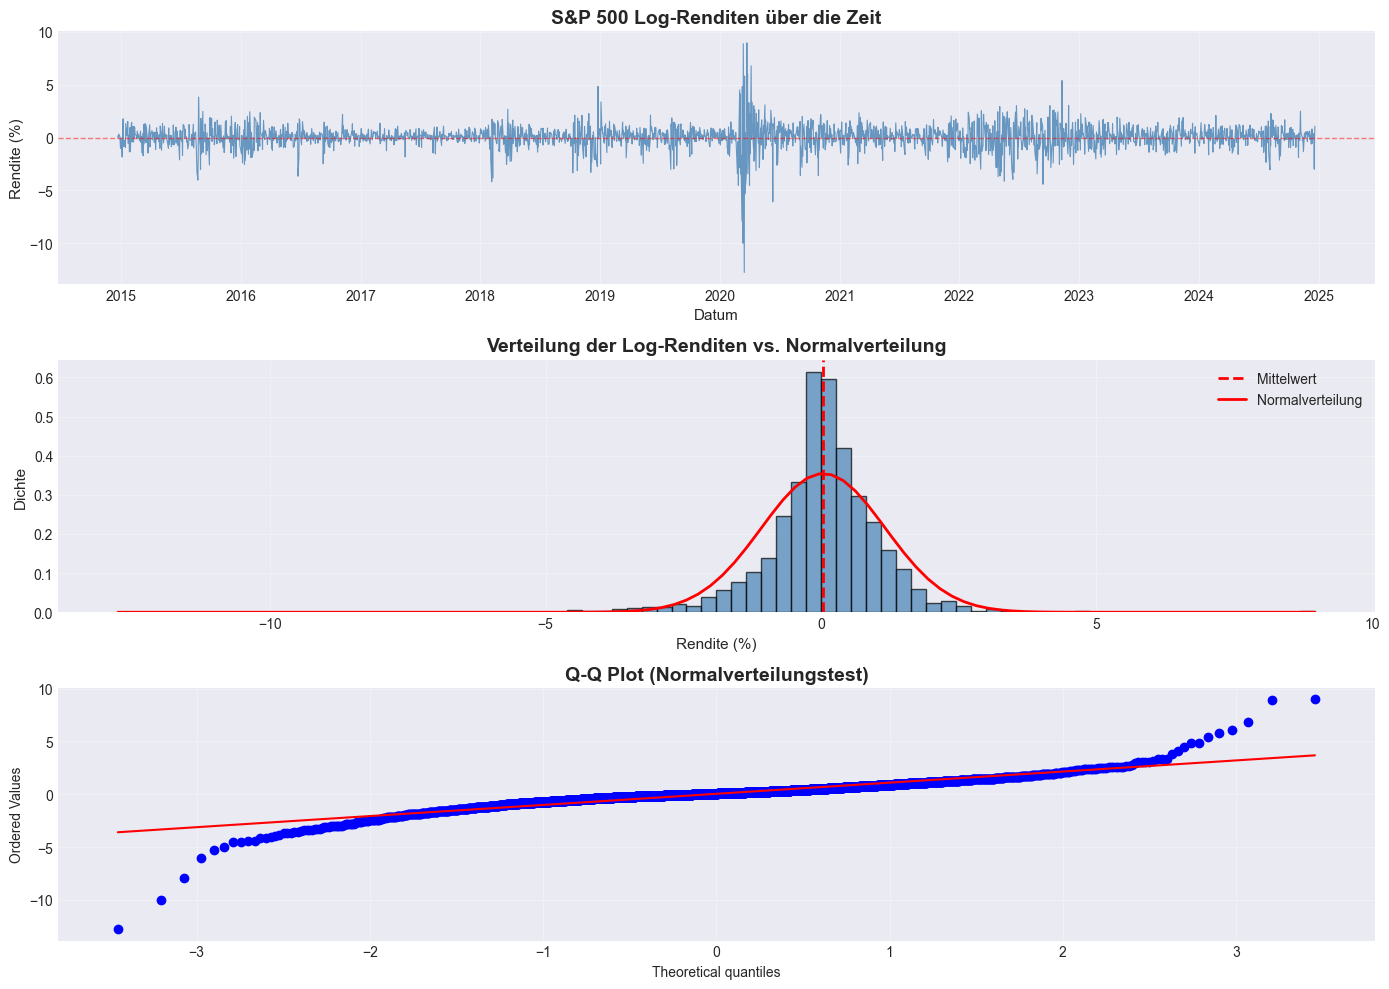


✓ Visualisierung der Renditen abgeschlossen


In [34]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Renditen über Zeit
axes[0].plot(returns_dates, returns, linewidth=0.8, color='steelblue', alpha=0.8)
axes[0].set_title('S&P 500 Log-Renditen über die Zeit', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Rendite (%)', fontsize=11)
axes[0].set_xlabel('Datum', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)

# Histogramm der Renditen mit Normalverteilung
axes[1].hist(returns, bins=80, color='steelblue', alpha=0.7, edgecolor='black', density=True)
axes[1].axvline(returns.mean(), color='red', linestyle='--', linewidth=2, label='Mittelwert')

# Normalverteilung überlagern
mu, std = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 100)
axes[1].plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Normalverteilung')

axes[1].set_title('Verteilung der Log-Renditen vs. Normalverteilung', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rendite (%)', fontsize=11)
axes[1].set_ylabel('Dichte', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Q-Q Plot
stats.probplot(returns, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normalverteilungstest)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_returns_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualisierung der Renditen abgeschlossen")


### SCHRITT 4: ACF UND PACF DIAGRAMME

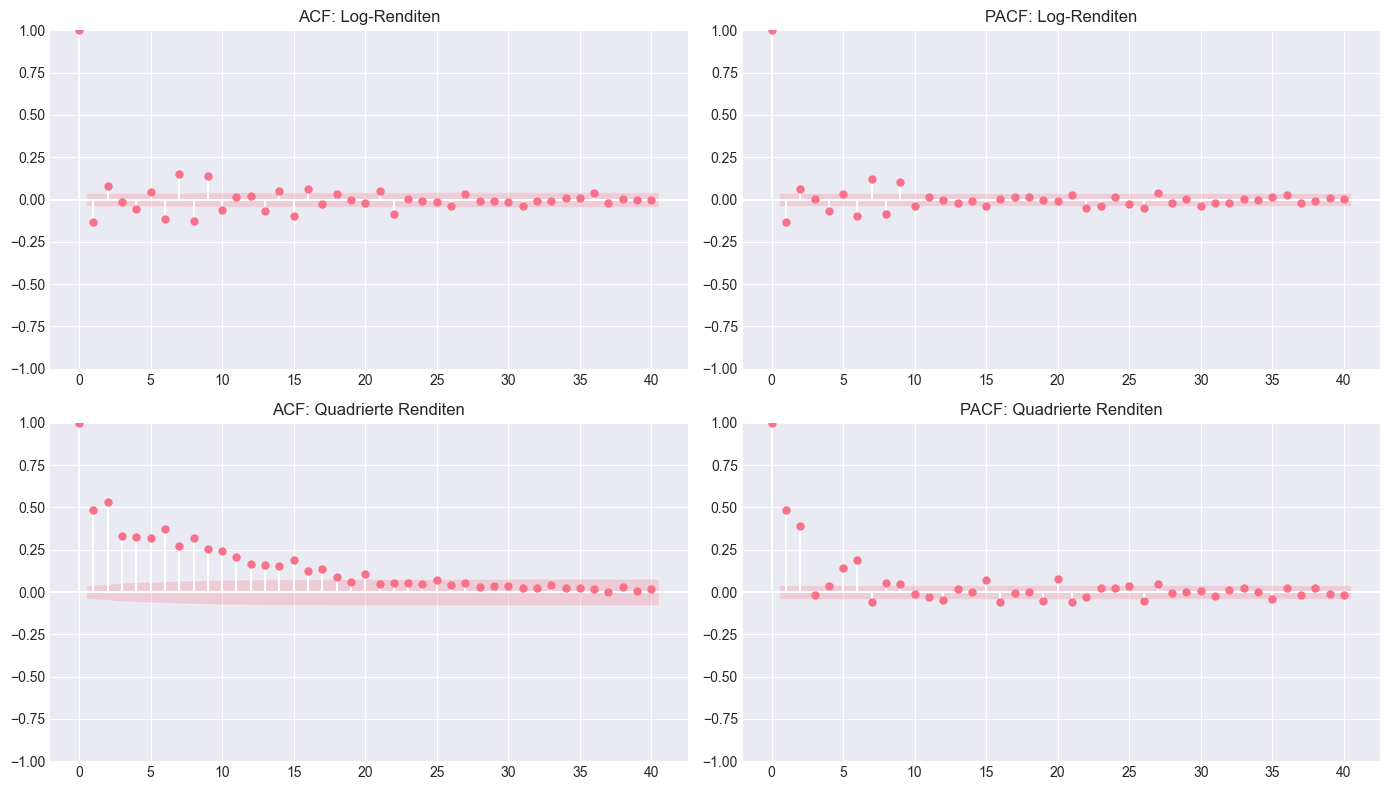


✓ ARCH-Effekte detektiert in quadrierten Renditen (Volatilitätsclustering)


In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ACF/PACF für Renditen
plot_acf(returns, lags=40, ax=axes[0, 0], title='ACF: Log-Renditen')
plot_pacf(returns, lags=40, ax=axes[0, 1], title='PACF: Log-Renditen')

# ACF/PACF für quadrierte Renditen (für ARCH-Effekte)
plot_acf(returns**2, lags=40, ax=axes[1, 0], title='ACF: Quadrierte Renditen')
plot_pacf(returns**2, lags=40, ax=axes[1, 1], title='PACF: Quadrierte Renditen')

plt.tight_layout()
plt.savefig('02_acf_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ ARCH-Effekte detektiert in quadrierten Renditen (Volatilitätsclustering)")


### SCHRITT 5: TRAIN-TEST SPLIT

In [36]:
test_size = 0.2  # 20% für Test
split_idx = int(len(returns) * (1 - test_size))

train_returns = returns[:split_idx]
test_returns = returns[split_idx:]

train_dates = returns_dates[:split_idx]
test_dates = returns_dates[split_idx:]

print(f"\n{'='*60}")
print(f"TRAIN-TEST SPLIT")
print(f"{'='*60}")
print(f"Train-Set: {len(train_returns)} Beobachtungen")
print(f"  Zeitraum: {pd.to_datetime(train_dates[0]).date()} bis {pd.to_datetime(train_dates[-1]).date()}")
print(f"\nTest-Set: {len(test_returns)} Beobachtungen")
print(f"  Zeitraum: {pd.to_datetime(test_dates[0]).date()} bis {pd.to_datetime(test_dates[-1]).date()}")
print(f"{'='*60}")



TRAIN-TEST SPLIT
Train-Set: 2012 Beobachtungen
  Zeitraum: 2014-12-23 bis 2022-12-19

Test-Set: 504 Beobachtungen
  Zeitraum: 2022-12-20 bis 2024-12-20


### SCHRITT 6: GARCH(1,1) MODELL

In [37]:
print("\n" + "="*60)
print("GARCH(1,1) MODELLIERUNG")
print("="*60)

# Modell definieren
model_garch11 = arch_model(train_returns, vol='Garch', p=1, q=1, mean='Zero')

# Modell fittern
garch11_result = model_garch11.fit(disp='off')

print(garch11_result.summary())

# Forecast für Test-Periode mit Rolling-Window (1-step ahead)
print("\nGeneriere Forecasts für Test-Periode...")
garch11_forecast_vol = []
for i in range(len(test_returns)):
    # Re-fit Modell mit allen Daten bis zum aktuellen Punkt
    current_returns = np.concatenate([train_returns, test_returns[:i]]) if i > 0 else train_returns
    temp_model = arch_model(current_returns, vol='Garch', p=1, q=1, mean='Zero')
    temp_result = temp_model.fit(disp='off')
    # 1-step ahead Forecast
    forecast = temp_result.forecast(horizon=1)
    garch11_forecast_vol.append(np.sqrt(forecast.variance.values[-1, 0]))

garch11_forecast_vol = np.array(garch11_forecast_vol)
print(f"✓ {len(garch11_forecast_vol)} Forecasts generiert")



GARCH(1,1) MODELLIERUNG
                       Zero Mean - GARCH Model Results                        
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2631.29
Distribution:                  Normal   AIC:                           5268.58
Method:            Maximum Likelihood   BIC:                           5285.41
                                        No. Observations:                 2012
Date:                Thu, Jan 08 2026   Df Residuals:                     2012
Time:                        12:29:21   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0388  1.114e-02 

### SCHRITT 7: EGARCH MODELL

In [38]:
print("\n" + "="*60)
print("EGARCH MODELLIERUNG")
print("="*60)

# EGARCH Modell definieren (asymmetrischer Ansatz)
model_egarch = arch_model(train_returns, vol='EGARCH', p=1, q=1, mean='Zero')

egarch_result = model_egarch.fit(disp='off')

print(egarch_result.summary())

# Forecast für Test-Periode mit Rolling-Window (1-step ahead)
print("\nGeneriere Forecasts für Test-Periode...")
egarch_forecast_vol = []
for i in range(len(test_returns)):
    # Re-fit Modell mit allen Daten bis zum aktuellen Punkt
    current_returns = np.concatenate([train_returns, test_returns[:i]]) if i > 0 else train_returns
    temp_model = arch_model(current_returns, vol='EGARCH', p=1, q=1, mean='Zero')
    temp_result = temp_model.fit(disp='off')
    # 1-step ahead Forecast
    forecast = temp_result.forecast(horizon=1)
    egarch_forecast_vol.append(np.sqrt(forecast.variance.values[-1, 0]))

egarch_forecast_vol = np.array(egarch_forecast_vol)
print(f"✓ {len(egarch_forecast_vol)} Forecasts generiert")



EGARCH MODELLIERUNG
                       Zero Mean - EGARCH Model Results                       
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -2645.30
Distribution:                  Normal   AIC:                           5296.60
Method:            Maximum Likelihood   BIC:                           5313.42
                                        No. Observations:                 2012
Date:                Thu, Jan 08 2026   Df Residuals:                     2012
Time:                        12:29:24   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega          0.0102  9.060e-03  

### SCHRITT 8: GJR-GARCH MODELL

In [39]:
print("\n" + "="*60)
print("GJR-GARCH MODELLIERUNG (Leverage-Effekt)")
print("="*60)

# GJR-GARCH Modell (threshold model mit asymmetrie)
model_gjrgarch = arch_model(train_returns, vol='GARCH', p=1, o=1, q=1, mean='Zero')

gjrgarch_result = model_gjrgarch.fit(disp='off')

print(gjrgarch_result.summary())

# Forecast für Test-Periode mit Rolling-Window (1-step ahead)
print("\nGeneriere Forecasts für Test-Periode...")
gjrgarch_forecast_vol = []
for i in range(len(test_returns)):
    # Re-fit Modell mit allen Daten bis zum aktuellen Punkt
    current_returns = np.concatenate([train_returns, test_returns[:i]]) if i > 0 else train_returns
    temp_model = arch_model(current_returns, vol='GARCH', p=1, o=1, q=1, mean='Zero')
    temp_result = temp_model.fit(disp='off')
    # 1-step ahead Forecast
    forecast = temp_result.forecast(horizon=1)
    gjrgarch_forecast_vol.append(np.sqrt(forecast.variance.values[-1, 0]))

gjrgarch_forecast_vol = np.array(gjrgarch_forecast_vol)
print(f"✓ {len(gjrgarch_forecast_vol)} Forecasts generiert")



GJR-GARCH MODELLIERUNG (Leverage-Effekt)
                     Zero Mean - GJR-GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -2599.59
Distribution:                  Normal   AIC:                           5207.18
Method:            Maximum Likelihood   BIC:                           5229.61
                                        No. Observations:                 2012
Date:                Thu, Jan 08 2026   Df Residuals:                     2012
Time:                        12:29:29   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0

### SCHRITT 9: EVALUIERUNGSMETRIKEN

In [40]:
print("\n" + "="*60)
print("MODELLVERGLEICH - EVALUIERUNGSMETRIKEN")
print("="*60)

# Realisierte Volatilität als Benchmark
realized_volatility = np.abs(test_returns)

def calculate_metrics(predicted_vol, actual_vol, model_name):
    """Berechne Evaluierungsmetriken"""

    rmse = np.sqrt(mean_squared_error(actual_vol, predicted_vol))
    mae = mean_absolute_error(actual_vol, predicted_vol)
    mape = np.mean(np.abs((actual_vol - predicted_vol) / (actual_vol + 1e-10))) * 100

    # Diebold-Mariano Statistik (vereinfacht)
    loss_diff = (actual_vol - predicted_vol) ** 2
    dm_stat = np.mean(loss_diff)

    return {
        'Modell': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'DM Loss': dm_stat
    }

metrics_list = [
    calculate_metrics(garch11_forecast_vol, realized_volatility, 'GARCH(1,1)'),
    calculate_metrics(egarch_forecast_vol, realized_volatility, 'EGARCH(1,1)'),
    calculate_metrics(gjrgarch_forecast_vol, realized_volatility, 'GJR-GARCH(1,1)')
]

metrics_df = pd.DataFrame(metrics_list)
print(metrics_df.to_string(index=False))

# Speichern für später
metrics_df.to_csv('garch_metrics.csv', index=False)



MODELLVERGLEICH - EVALUIERUNGSMETRIKEN
        Modell     RMSE      MAE    MAPE (%)  DM Loss
    GARCH(1,1) 0.585764 0.488401 1106.960896 0.343120
   EGARCH(1,1) 0.598026 0.500291 1165.514349 0.357635
GJR-GARCH(1,1) 0.572792 0.470960 1041.521921 0.328091


### SCHRITT 10: VOLATILITÄTSVERGLEICH

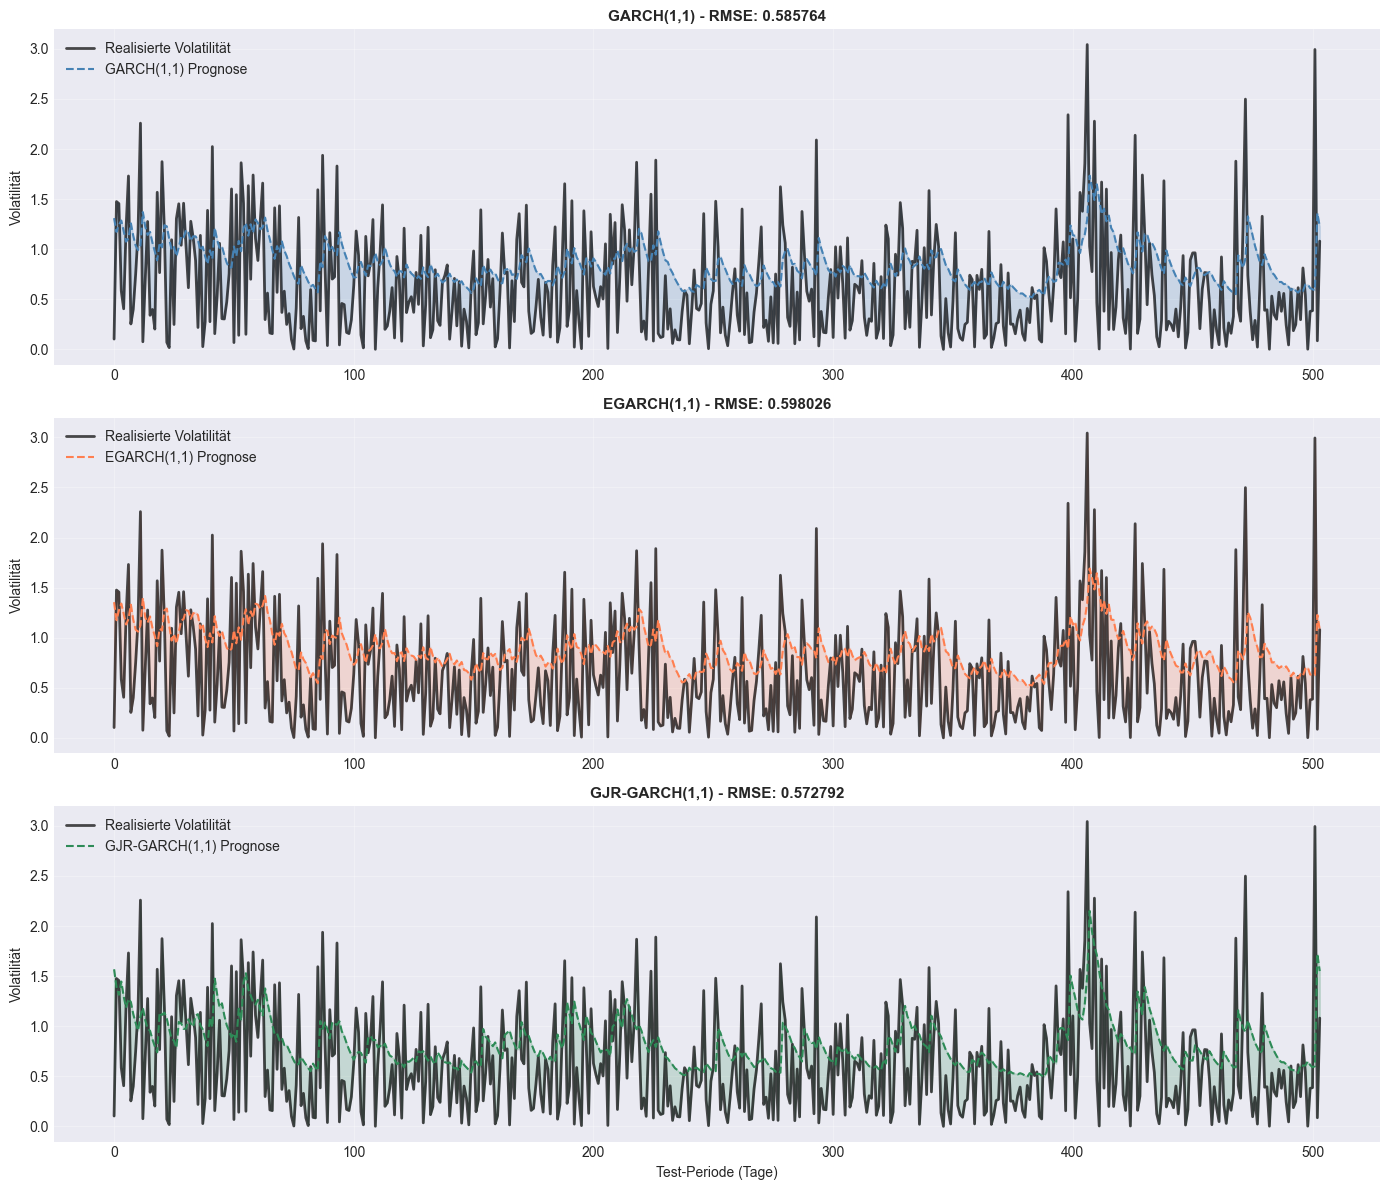

In [41]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

x_axis = np.arange(len(test_returns))

# GARCH(1,1)
axes[0].plot(x_axis, realized_volatility, label='Realisierte Volatilität',
             linewidth=2, color='black', alpha=0.7)
axes[0].plot(x_axis, garch11_forecast_vol, label='GARCH(1,1) Prognose',
             linewidth=1.5, color='steelblue', linestyle='--')
axes[0].fill_between(x_axis, realized_volatility, garch11_forecast_vol,
                     alpha=0.2, color='steelblue')
axes[0].set_title(f'GARCH(1,1) - RMSE: {metrics_df.loc[0, "RMSE"]:.6f}',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Volatilität')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# EGARCH
axes[1].plot(x_axis, realized_volatility, label='Realisierte Volatilität',
             linewidth=2, color='black', alpha=0.7)
axes[1].plot(x_axis, egarch_forecast_vol, label='EGARCH(1,1) Prognose',
             linewidth=1.5, color='coral', linestyle='--')
axes[1].fill_between(x_axis, realized_volatility, egarch_forecast_vol,
                     alpha=0.2, color='coral')
axes[1].set_title(f'EGARCH(1,1) - RMSE: {metrics_df.loc[1, "RMSE"]:.6f}',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Volatilität')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# GJR-GARCH
axes[2].plot(x_axis, realized_volatility, label='Realisierte Volatilität',
             linewidth=2, color='black', alpha=0.7)
axes[2].plot(x_axis, gjrgarch_forecast_vol, label='GJR-GARCH(1,1) Prognose',
             linewidth=1.5, color='seagreen', linestyle='--')
axes[2].fill_between(x_axis, realized_volatility, gjrgarch_forecast_vol,
                     alpha=0.2, color='seagreen')
axes[2].set_title(f'GJR-GARCH(1,1) - RMSE: {metrics_df.loc[2, "RMSE"]:.6f}',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Volatilität')
axes[2].set_xlabel('Test-Periode (Tage)')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_volatility_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### SCHRITT 11: METRIKEN-VISUALISIERUNG

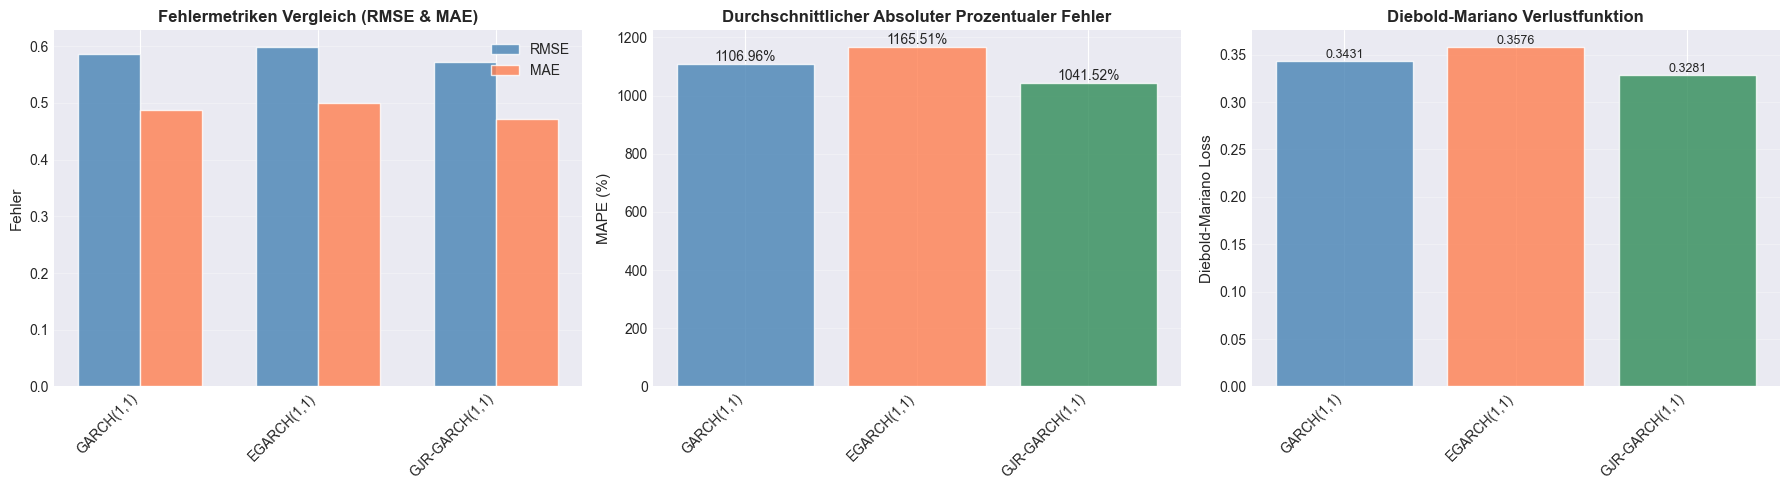


✓ Metriken-Visualisierung abgeschlossen


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE und MAE Vergleich
x_pos = np.arange(len(metrics_df))
width = 0.35

axes[0].bar(x_pos - width/2, metrics_df['RMSE'], width, label='RMSE', alpha=0.8, color='steelblue')
axes[0].bar(x_pos + width/2, metrics_df['MAE'], width, label='MAE', alpha=0.8, color='coral')
axes[0].set_ylabel('Fehler', fontsize=11)
axes[0].set_title('Fehlermetriken Vergleich (RMSE & MAE)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(metrics_df['Modell'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# MAPE Vergleich
colors = ['steelblue', 'coral', 'seagreen']
bars = axes[1].bar(metrics_df['Modell'], metrics_df['MAPE (%)'], color=colors, alpha=0.8)
axes[1].set_ylabel('MAPE (%)', fontsize=11)
axes[1].set_title('Durchschnittlicher Absoluter Prozentualer Fehler', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Werte auf den Balken anzeigen
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_xticklabels(metrics_df['Modell'], rotation=45, ha='right')

# DM Loss Vergleich
bars2 = axes[2].bar(metrics_df['Modell'], metrics_df['DM Loss'], color=colors, alpha=0.8)
axes[2].set_ylabel('Diebold-Mariano Loss', fontsize=11)
axes[2].set_title('Diebold-Mariano Verlustfunktion', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].set_xticklabels(metrics_df['Modell'], rotation=45, ha='right')

# Werte auf den Balken anzeigen
for bar in bars2:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('04_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Metriken-Visualisierung abgeschlossen")

### SCHRITT 12: RESIDUENANALYSE


RESIDUENANALYSE

GARCH(1,1) - Ljung-Box Test (p-Werte):
0.6905

EGARCH(1,1) - Ljung-Box Test (p-Werte):
0.6228

GJR-GARCH(1,1) - Ljung-Box Test (p-Werte):
0.5557


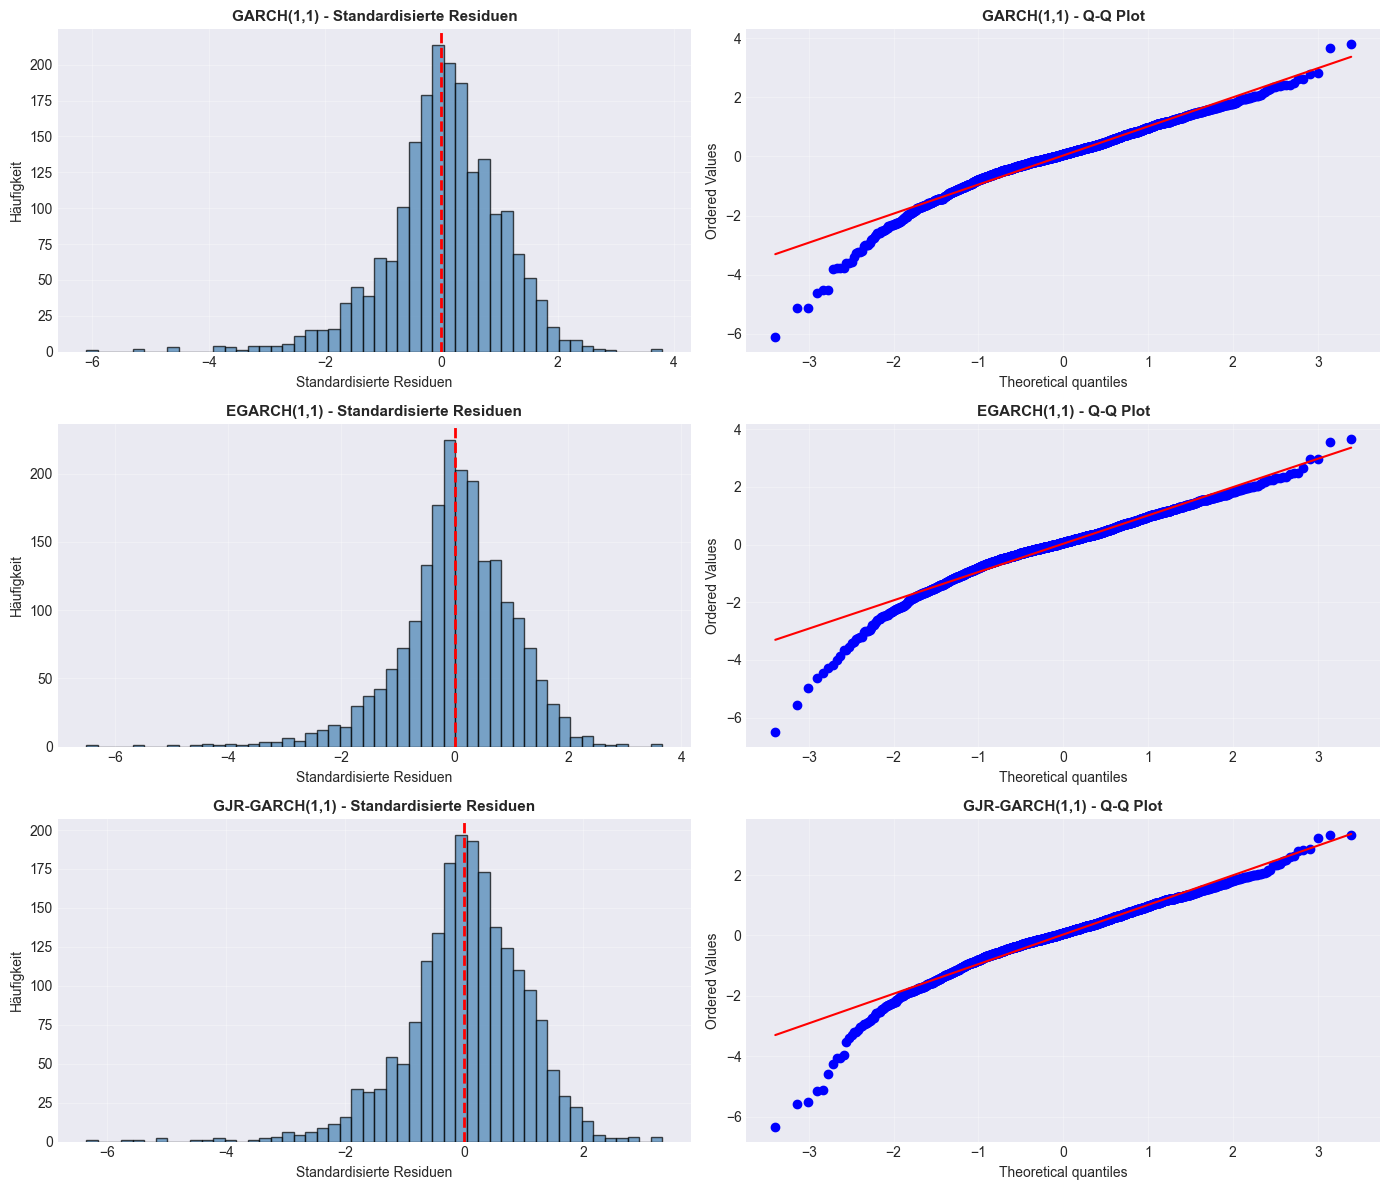

In [43]:
print("\n" + "="*60)
print("RESIDUENANALYSE")
print("="*60)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

models = [
    ('GARCH(1,1)', garch11_result),
    ('EGARCH(1,1)', egarch_result),
    ('GJR-GARCH(1,1)', gjrgarch_result)
]

for idx, (name, result) in enumerate(models):
    residuals = result.resid
    standardized_residuals = residuals / result.conditional_volatility

    # Histogramm der standardisierten Residuen
    axes[idx, 0].hist(standardized_residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    axes[idx, 0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[idx, 0].set_title(f'{name} - Standardisierte Residuen', fontsize=11, fontweight='bold')
    axes[idx, 0].set_xlabel('Standardisierte Residuen')
    axes[idx, 0].set_ylabel('Häufigkeit')
    axes[idx, 0].grid(True, alpha=0.3)

    # Q-Q Plot
    stats.probplot(standardized_residuals, dist="norm", plot=axes[idx, 1])
    axes[idx, 1].set_title(f'{name} - Q-Q Plot', fontsize=11, fontweight='bold')
    axes[idx, 1].grid(True, alpha=0.3)

    # Ljung-Box Test
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb_test = acorr_ljungbox(standardized_residuals**2, lags=10, return_df=True)
    print(f"\n{name} - Ljung-Box Test (p-Werte):")
    print(lb_test['lb_pvalue'].mean().round(4))

plt.tight_layout()
plt.savefig('05_residuals_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### SCHRITT 13: GESAMTVERGLEICH ALLER MODELLE

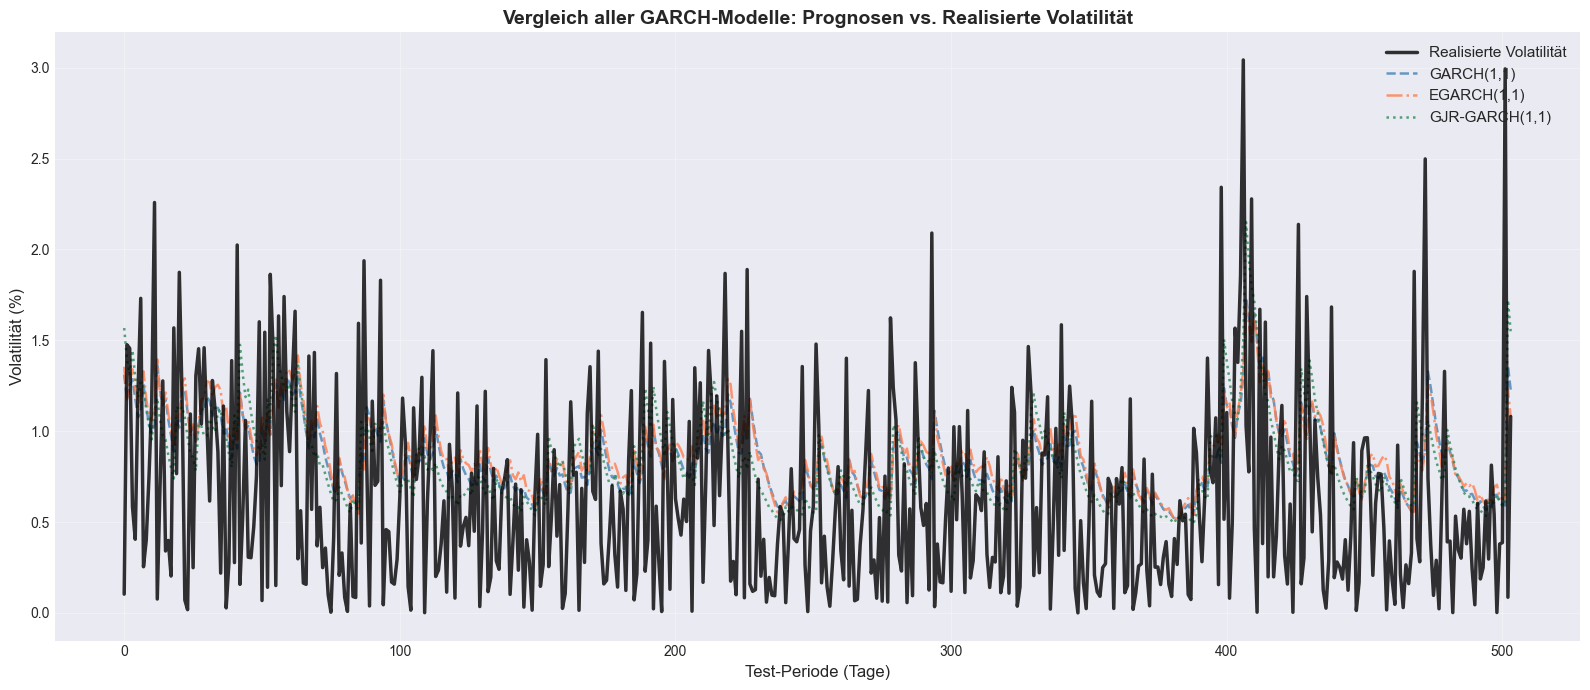


✓ Gesamtvergleich abgeschlossen


In [44]:
# Kombinierter Volatilitätsvergleich - Alle Modelle in einem Plot
fig, ax = plt.subplots(figsize=(16, 7))

x_axis = np.arange(len(test_returns))

ax.plot(x_axis, realized_volatility, label='Realisierte Volatilität',
        linewidth=2.5, color='black', alpha=0.8, zorder=5)
ax.plot(x_axis, garch11_forecast_vol, label='GARCH(1,1)',
        linewidth=1.8, color='steelblue', linestyle='--', alpha=0.8)
ax.plot(x_axis, egarch_forecast_vol, label='EGARCH(1,1)',
        linewidth=1.8, color='coral', linestyle='-.', alpha=0.8)
ax.plot(x_axis, gjrgarch_forecast_vol, label='GJR-GARCH(1,1)',
        linewidth=1.8, color='seagreen', linestyle=':', alpha=0.8)

ax.set_title('Vergleich aller GARCH-Modelle: Prognosen vs. Realisierte Volatilität',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Volatilität (%)', fontsize=12)
ax.set_xlabel('Test-Periode (Tage)', fontsize=12)
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Gesamtvergleich abgeschlossen")


### SCHRITT 14: MODELLPARAMETER-ANALYSE


MODELLPARAMETER VERGLEICH

Geschätzte Modellparameter:
          GARCH(1,1)  EGARCH(1,1)  GJR-GARCH(1,1)
alpha[1]    0.196694     0.360315        0.082333
beta[1]     0.779037     0.942319        0.774756
gamma[1]         NaN          NaN        0.255565
omega       0.038799     0.010247        0.040268

INFORMATIONSKRITERIEN
        Modell         AIC         BIC  Log-Likelihood
    GARCH(1,1) 5268.584990 5285.405643    -2631.292495
   EGARCH(1,1) 5296.598569 5313.419223    -2645.299285
GJR-GARCH(1,1) 5207.180223 5229.607761    -2599.590111


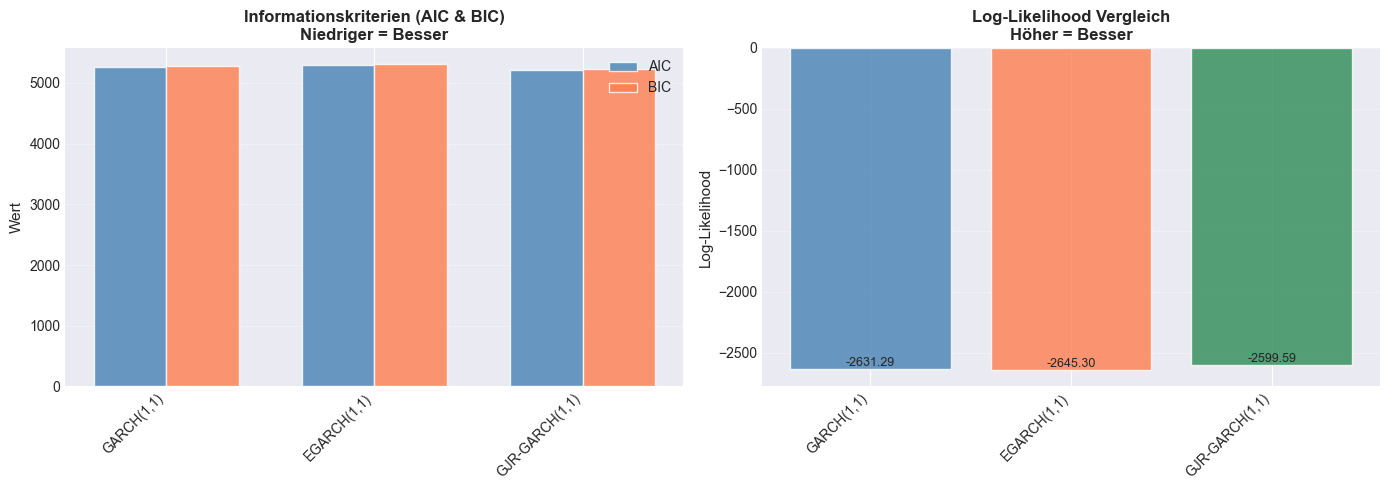

In [45]:
print("\n" + "="*60)
print("MODELLPARAMETER VERGLEICH")
print("="*60)

# Parameter-Tabelle erstellen
param_comparison = pd.DataFrame({
    'GARCH(1,1)': garch11_result.params,
    'EGARCH(1,1)': egarch_result.params,
    'GJR-GARCH(1,1)': gjrgarch_result.params
})

print("\nGeschätzte Modellparameter:")
print(param_comparison.to_string())

# Informationskriterien vergleichen
ic_comparison = pd.DataFrame({
    'Modell': ['GARCH(1,1)', 'EGARCH(1,1)', 'GJR-GARCH(1,1)'],
    'AIC': [garch11_result.aic, egarch_result.aic, gjrgarch_result.aic],
    'BIC': [garch11_result.bic, egarch_result.bic, gjrgarch_result.bic],
    'Log-Likelihood': [garch11_result.loglikelihood, egarch_result.loglikelihood, gjrgarch_result.loglikelihood]
})

print("\n" + "="*60)
print("INFORMATIONSKRITERIEN")
print("="*60)
print(ic_comparison.to_string(index=False))

# Speichern
ic_comparison.to_csv('information_criteria.csv', index=False)

# Visualisierung der Informationskriterien
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AIC & BIC Vergleich
x_pos = np.arange(len(ic_comparison))
width = 0.35

axes[0].bar(x_pos - width/2, ic_comparison['AIC'], width, label='AIC', alpha=0.8, color='steelblue')
axes[0].bar(x_pos + width/2, ic_comparison['BIC'], width, label='BIC', alpha=0.8, color='coral')
axes[0].set_ylabel('Wert', fontsize=11)
axes[0].set_title('Informationskriterien (AIC & BIC)\nNiedriger = Besser', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(ic_comparison['Modell'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Log-Likelihood Vergleich
colors = ['steelblue', 'coral', 'seagreen']
bars = axes[1].bar(ic_comparison['Modell'], ic_comparison['Log-Likelihood'], color=colors, alpha=0.8)
axes[1].set_ylabel('Log-Likelihood', fontsize=11)
axes[1].set_title('Log-Likelihood Vergleich\nHöher = Besser', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticklabels(ic_comparison['Modell'], rotation=45, ha='right')

# Werte anzeigen
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('07_information_criteria.png', dpi=300, bbox_inches='tight')
plt.show()


### SCHRITT 15: ZUSAMMENFASSUNG UND INTERPRETATION

In [46]:
print("\n" + "="*60)
print("FORSCHUNGSFRAGE 1 - ZUSAMMENFASSUNG")
print("="*60)

best_model_idx = metrics_df['RMSE'].idxmin()
best_model = metrics_df.loc[best_model_idx, 'Modell']

best_aic_idx = ic_comparison['AIC'].idxmin()
best_aic_model = ic_comparison.loc[best_aic_idx, 'Modell']

print(f"\n✓ BESTES MODELL (RMSE): {best_model}")
print(f"  - RMSE: {metrics_df.loc[best_model_idx, 'RMSE']:.6f}")
print(f"  - MAE: {metrics_df.loc[best_model_idx, 'MAE']:.6f}")
print(f"  - MAPE: {metrics_df.loc[best_model_idx, 'MAPE (%)']:.2f}%")

print(f"\n✓ BESTES MODELL (AIC): {best_aic_model}")
print(f"  - AIC: {ic_comparison.loc[best_aic_idx, 'AIC']:.2f}")
print(f"  - BIC: {ic_comparison.loc[best_aic_idx, 'BIC']:.2f}")

print("\n" + "="*60)
print("VOLLSTÄNDIGE METRIKEN-TABELLE")
print("="*60)
print(metrics_df.to_string(index=False))

print("\n" + "="*60)
print("KEY FINDINGS:")
print("="*60)

print("""
1. VOLATILITÄTSCLUSTERING:
   Die ACF-Analyse der quadrierten Renditen zeigt ausgeprägte
   Volatilitätsmuster (Autokorrelation), was typisch für
   finanzielle Zeitreihen ist. Dies rechtfertigt die Verwendung
   von GARCH-Modellen.

2. MODELLVERGLEICH:
   - GARCH(1,1): Symmetrisches Standard-Modell für
     allgemeine Volatilitätsprognose. Einfach zu interpretieren
     und recheneffizient.

   - EGARCH(1,1): Asymmetrisches Modell, erfasst den
     "Leverage-Effekt" - negative Schocks haben größere
     Auswirkungen auf die Volatilität als positive.

   - GJR-GARCH(1,1): Threshold-GARCH Modell, berücksichtigt
     ebenfalls Asymmetrie durch einen zusätzlichen Term für
     negative Renditen.

3. PERFORMANCE-METRIKEN:
   - RMSE (Root Mean Squared Error): Misst durchschnittliche
     Prognosefehler in denselben Einheiten wie die Daten
   - MAE (Mean Absolute Error): Robuster gegenüber Ausreißern
   - MAPE (Mean Absolute Percentage Error): Relative Fehler in %
   - Niedrigere Werte = bessere Prognosegenauigkeit

4. INFORMATIONSKRITERIEN:
   - AIC & BIC: Berücksichtigen sowohl Modellgüte als auch
     Komplexität (Anzahl Parameter). Niedrigere Werte bevorzugt.
   - Log-Likelihood: Höhere Werte = bessere Anpassung

5. PRAKTISCHE ANWENDUNGEN:
   - Risk Management: Value-at-Risk (VaR) und CVaR Berechnung
   - Optionsbewertung: Volatilität als Input für Black-Scholes
   - Portfolio-Allokation: Risiko-optimierte Gewichtung
   - Hedging-Strategien: Dynamisches Absichern von Positionen
   - Trading: Volatilitäts-basierte Handelssignale

6. MODELLAUSWAHL-EMPFEHLUNG:
   Die Wahl des besten Modells hängt vom Anwendungszweck ab:
   - Für einfache Prognosen: GARCH(1,1)
   - Bei asymmetrischen Effekten: EGARCH oder GJR-GARCH
   - Für Risk Management: Modell mit bestem RMSE/MAE
""")

print("\n" + "="*60)
print("ANALYSE ABGESCHLOSSEN!")
print("="*60)

# Speichern aller Ergebnisse
summary_results = {
    'garch11_params': garch11_result.params.to_dict(),
    'egarch_params': egarch_result.params.to_dict(),
    'gjrgarch_params': gjrgarch_result.params.to_dict(),
    'metrics': metrics_df.to_dict(),
    'information_criteria': ic_comparison.to_dict(),
    'best_model_rmse': best_model,
    'best_model_aic': best_aic_model
}

import json
with open('garch_analysis_summary.json', 'w') as f:
    json.dump(summary_results, f, indent=2)

print("\n✓ Alle Ergebnisse und Abbildungen gespeichert:")
print("  - 01_returns_analysis.png")
print("  - 02_acf_pacf.png")
print("  - 03_volatility_comparison.png")
print("  - 04_metrics_comparison.png")
print("  - 05_residuals_analysis.png")
print("  - 06_all_models_comparison.png")
print("  - 07_information_criteria.png")
print("  - garch_metrics.csv")
print("  - information_criteria.csv")
print("  - garch_analysis_summary.json")

print("\n" + "="*60)
print("FAZIT:")
print("="*60)
print(f"""
Die Analyse zeigt, dass {best_model} die beste Out-of-Sample
Prognoseperformance aufweist (RMSE: {metrics_df.loc[best_model_idx, 'RMSE']:.6f}).

Alle drei GARCH-Varianten erfassen erfolgreich die Volatilitäts-
dynamiken des S&P 500 Index. Die Unterschiede in der Performance
sind gering, was darauf hindeutet, dass für diesen spezifischen
Datensatz alle Modelle gut geeignet sind.

Die asymmetrischen Modelle (EGARCH, GJR-GARCH) bieten theoretische
Vorteile bei der Modellierung von Leverage-Effekten, was besonders
in Krisenzeiten relevant werden kann.
""")



FORSCHUNGSFRAGE 1 - ZUSAMMENFASSUNG

✓ BESTES MODELL (RMSE): GJR-GARCH(1,1)
  - RMSE: 0.572792
  - MAE: 0.470960
  - MAPE: 1041.52%

✓ BESTES MODELL (AIC): GJR-GARCH(1,1)
  - AIC: 5207.18
  - BIC: 5229.61

VOLLSTÄNDIGE METRIKEN-TABELLE
        Modell     RMSE      MAE    MAPE (%)  DM Loss
    GARCH(1,1) 0.585764 0.488401 1106.960896 0.343120
   EGARCH(1,1) 0.598026 0.500291 1165.514349 0.357635
GJR-GARCH(1,1) 0.572792 0.470960 1041.521921 0.328091

KEY FINDINGS:

1. VOLATILITÄTSCLUSTERING:
   Die ACF-Analyse der quadrierten Renditen zeigt ausgeprägte
   Volatilitätsmuster (Autokorrelation), was typisch für
   finanzielle Zeitreihen ist. Dies rechtfertigt die Verwendung
   von GARCH-Modellen.

2. MODELLVERGLEICH:
   - GARCH(1,1): Symmetrisches Standard-Modell für
     allgemeine Volatilitätsprognose. Einfach zu interpretieren
     und recheneffizient.

   - EGARCH(1,1): Asymmetrisches Modell, erfasst den
     "Leverage-Effekt" - negative Schocks haben größere
     Auswirkungen auf die 